# Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import pyarrow
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import scipy.stats as stats
import plotly.express as px
from datetime import date

# Data

In [2]:
features_df = pd.read_parquet(r"..\data\features\features.parquet", engine="pyarrow")

# Data preprocessing

In [3]:
# Mobile mean with a window of one hour
hours = 1
# Apply filters to the time series of the features
features_df = features_df[(features_df['energy']>=0)&(features_df['kurtosis']<2500)&(features_df['frequency_index']>=-3)&(features_df['entropy']>=0)&(features_df['entropy']<15000)]
# Calculate moving average for all features
features_df['energy_mobile_mean'] = np.log10(features_df['energy'].rolling(window=11*hours, center=False).mean())
features_df['kurtosis_mobile_mean'] = np.log10(features_df['kurtosis'].rolling(window=11*hours, center=False).mean())
features_df['frequency_index_mobile_mean'] = features_df['frequency_index'].rolling(window=11*hours, center=False).mean()
features_df['entropy_mobile_mean'] = features_df['entropy'].rolling(window=11*hours, center=False).mean()
features_df['energy'] = np.log10(features_df['energy'])
features_df['kurtosis'] = np.log10(features_df['kurtosis'])

## Training set

In [4]:
# Select just one month of data
features_df_1_month = features_df[features_df['timestamp']<"2022-02-01"]
# Filter the first eleven observations with NAs values
features_df_1_month = features_df_1_month.dropna(subset=['energy_mobile_mean'])

In [5]:
# Take descriptive variables
variables = ["energy_mobile_mean",	"kurtosis_mobile_mean", "frequency_index_mobile_mean", "entropy_mobile_mean"]
X = features_df_1_month[["energy_mobile_mean",	"kurtosis_mobile_mean",	
                         "frequency_index_mobile_mean", "entropy_mobile_mean"]].to_numpy()

print(X.shape)

(8883, 4)


In [6]:
# Scale variables
scaler = StandardScaler().fit(X)
X = scaler.transform(X)

## Dimensionality reduction

### PCA

### Model with three PC

In [7]:
# Create a PCA object and train it
pca = PCA(n_components=3).fit(X)
# Transform the data to the new reducted space
Z = pca.transform(X)
print(Z.shape)

(8883, 3)


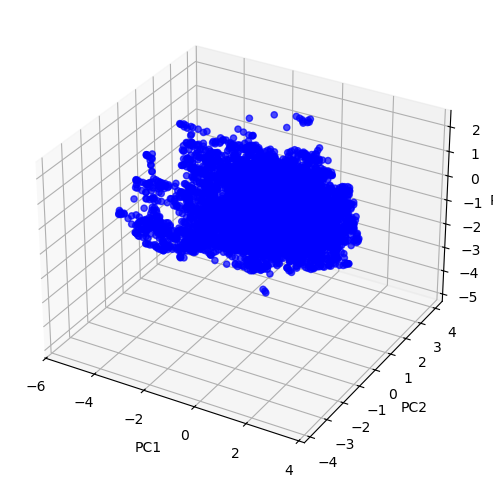

In [9]:
# Plot in the new space
"""
fig = px.scatter_3d(
                    x=Z[:, 0],
                    y=Z[:, 1],
                    z=Z[:, 2],
                    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3'},
                    title='PCA 3D projection',
                    opacity=0.7
                )
fig.update_traces(marker=dict(size=3))
fig.show()
"""

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c='b', s=20, alpha=0.7)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.grid(True)
plt.show()

## Clustering

### Find the best local minima

In [ ]:
"""
import random
import numpy as np

# Run KMeans multiple times and keep the best model
n_iterations = 100  # Number of times to run KMeans
n_clusters = 3

best_model = None
best_labels = None
best_score = -np.inf
best_seed = None

for i in range(n_iterations):
    seed = random.randint(1, 10000)
    km_temp = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10).fit(Z)
    labels_temp = km_temp.labels_
    score = silhouette_score(Z, labels_temp)
    print(score)

    if score > best_score:
        best_score = score
        best_model = km_temp
        best_labels = labels_temp
        best_seed = seed

km_model = best_model

print(f"\nBest silhouette score: {best_score:.4f}")
"""

0.32442051366033514
0.324468709020017
0.3244743531479399
0.32442051366033514
0.3244743531479399
0.32429078423907554
0.324468709020017
0.324468709020017
0.3245068115613664
0.324468709020017
0.32442051366033514
0.3244743531479399
0.3244743531479399
0.32442051366033514
0.3244743531479399
0.32442051366033514
0.324468709020017
0.32442051366033514
0.32442051366033514
0.32442051366033514
0.32309848105636285
0.32442051366033514
0.3244743531479399
0.32442051366033514
0.3244743531479399
0.3244743531479399
0.3244743531479399
0.3244743531479399
0.3244743531479399
0.3244743531479399
0.32442051366033514
0.32442051366033514
0.32442051366033514
0.32442051366033514
0.32404997677367586
0.324468709020017
0.32442051366033514
0.32442051366033514
0.324468709020017
0.32442051366033514
0.32442051366033514
0.324468709020017
0.32442051366033514
0.3244743531479399
0.32442051366033514
0.3244743531479399
0.324468709020017
0.3244743531479399
0.3244743531479399
0.324468709020017
0.3244743531479399
0.3244743531479399

In [ ]:
# print(best_seed)

1439


In [26]:
km_model = KMeans(n_clusters=3, random_state=9972, n_init=10).fit(Z)

In [27]:
silhouette_score(Z, km_model.labels_)

0.3246819831882183

In [28]:
labels = km_model.labels_

fig = px.scatter_3d(
    x=Z[:, 0],
    y=Z[:, 1],
    z=Z[:, 2],
    color=labels,
    color_continuous_scale='viridis',  # Changed from cmap and added the missing comma
    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Cluster'},
    title='Principal Components Analysis Plot (Interactive 3D)',
    opacity=0.8,
)

fig.update_traces(marker=dict(size=4))
fig.show()

Mandar las observaciones del grupo 2 a la Doctora

In [29]:
# Create a dataframe with the clustering data
clustering_data = pd.DataFrame(Z, columns= ['PC1', 'PC2', 'PC3'])
clustering_data['labels'] = km_model.labels_
# Create a dataframe with the clustering data
km_model.cluster_centers_ = clustering_data.groupby('labels')[['PC1','PC2', 'PC3']].mean().values

C:\Users\javie\AppData\Local\Temp\ipykernel_19236\4112878207.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


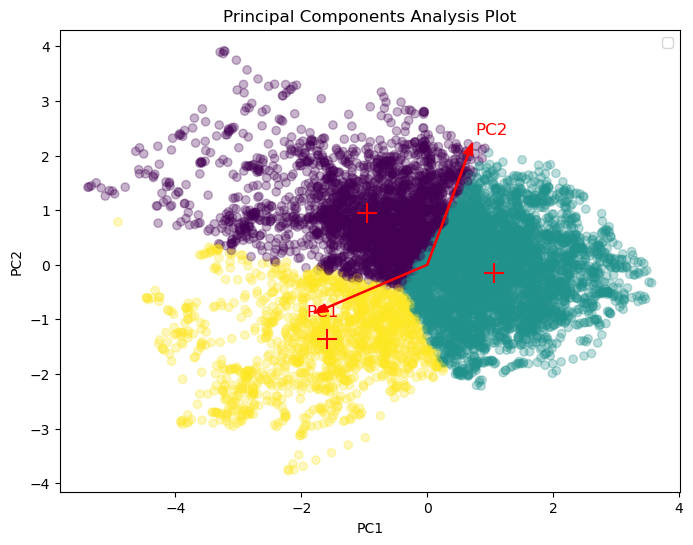

In [30]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(Z[:, 0], Z[:, 1], c=labels, cmap='viridis', alpha=0.3)
plt.scatter(km_model.cluster_centers_[:, 0], km_model.cluster_centers_[:, 1], c='red', s=200, marker='+')
# Plot principal component axes
origin = np.mean(Z[:, :2], axis=0)
for i, (vec, var) in enumerate(zip(pca.components_[:2], pca.explained_variance_ratio_[:2])):
    plt.arrow(origin[0], origin[1], vec[0]*3, vec[1]*3, color='red', width=0.02, head_width=0.15, length_includes_head=True)
    plt.text(origin[0] + vec[0]*3.2, origin[1] + vec[1]*3.2, f'PC{i+1}', color='red', fontsize=12)
plt.title('Principal Components Analysis Plot')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

##### Groups distribution

In [31]:
clustering_data[['labels','PC1']].groupby('labels').count()

,PC1
labels,
0,2775
1,4649
2,1459


## Result analysis

In [60]:
observed_data = features_df_1_month.copy()
observed_data['labels'] = km_model.labels_

In [61]:
print(observed_data[observed_data['timestamp'].isna()])

Empty DataFrame
Columns: [timestamp, energy, kurtosis, frecuency_index, entropy, frequency_index, energy_mobile_mean, kurtosis_mobile_mean, frequency_index_mobile_mean, entropy_mobile_mean, labels]
Index: []


In [64]:
len(observed_data)

8883

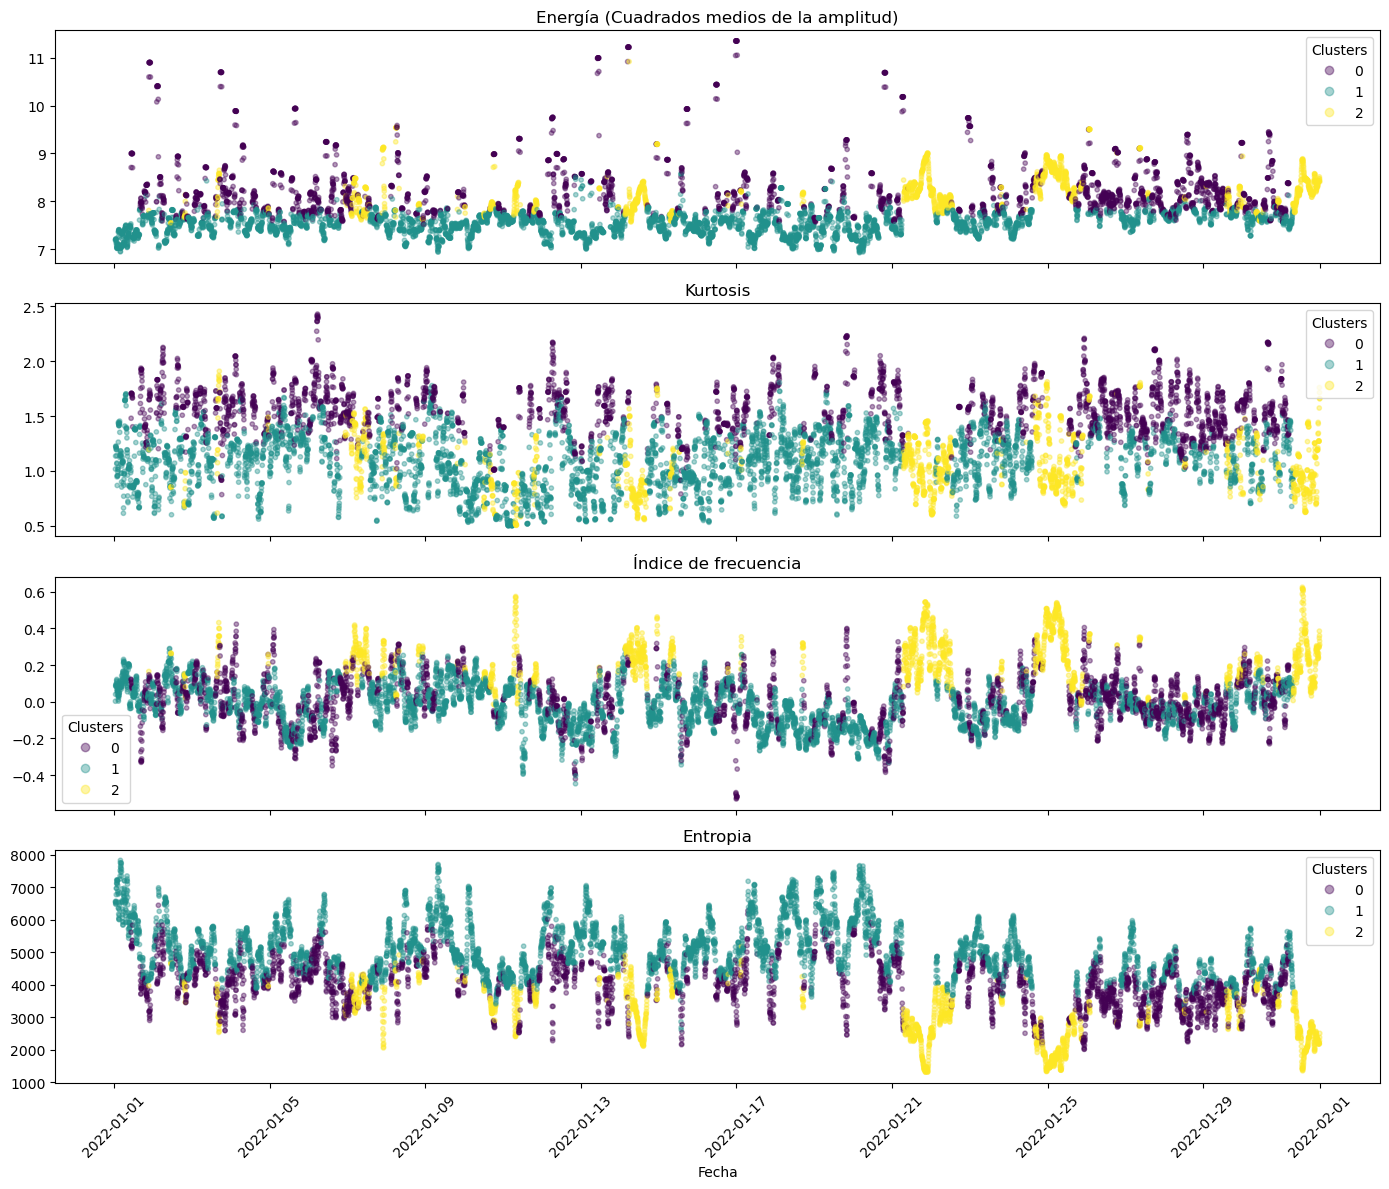

In [66]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(observed_data['timestamp'], observed_data['energy_mobile_mean'], c=observed_data['labels'], cmap='viridis', s=10, alpha=0.4)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(observed_data['timestamp'], observed_data['kurtosis_mobile_mean'], c=observed_data['labels'], cmap='viridis', s=10, alpha=0.4)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(observed_data['timestamp'], observed_data['frequency_index_mobile_mean'], c=observed_data['labels'], cmap='viridis', s=10, alpha=0.4)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(observed_data['timestamp'], observed_data['entropy_mobile_mean'], c=observed_data['labels'], cmap='viridis', s=10, alpha=0.4)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")

plt.xticks(rotation=45)
plt.tight_layout()

We can observe that the clustering is capturing the interested behavior, the group 2 seems to be the state representing the increased activity in the Popocatepetl volcano

## Identify outliers

In [35]:
km_model

KMeans(n_clusters=3, n_init=10, random_state=9972)

In [36]:
distances = km_model.transform(Z)
clustering_data['distance_to_centroid'] = [distances[i, label] for i, label in enumerate(km_model.labels_)]

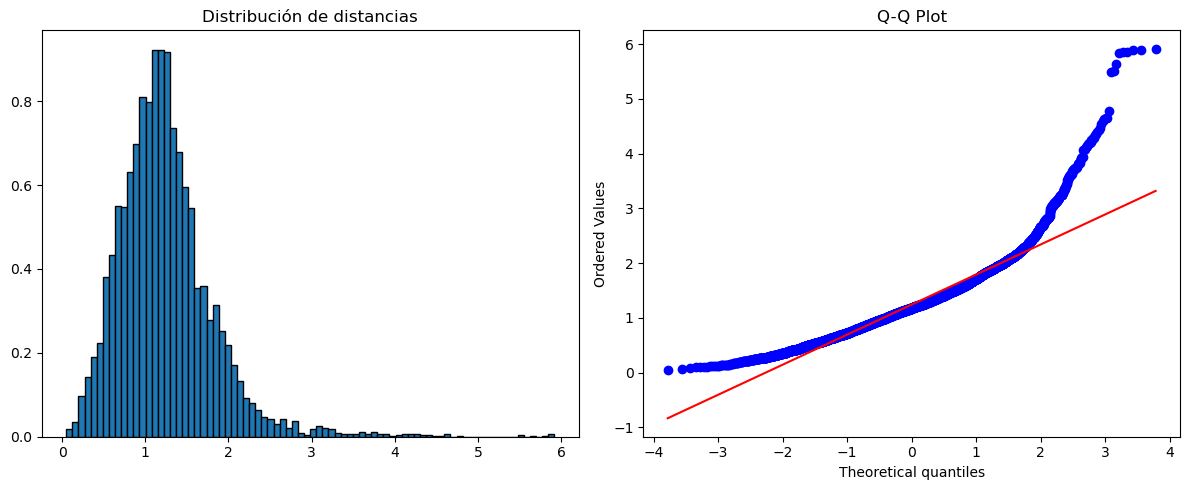

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma
axes[0].hist(clustering_data['distance_to_centroid'], bins=80, density=True, edgecolor='black')
axes[0].set_title('Distribución de distancias')

# Q-Q plot
stats.probplot(clustering_data['distance_to_centroid'], plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

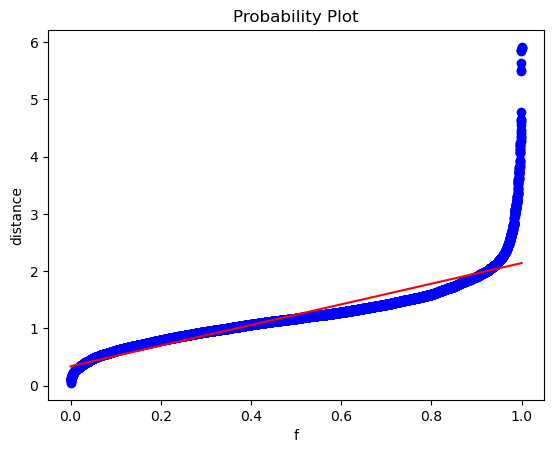

In [40]:
from scipy import stats


data = clustering_data['distance_to_centroid'].dropna()

# Simple QQ plot against a Uniform distribution (0,1)
stats.probplot(data, dist='uniform', plot=plt)
plt.xlabel('f')
plt.ylabel('distance')
plt.show()

In [41]:
# Rango de valores observados
np.min(clustering_data['distance_to_centroid']),np.max(clustering_data['distance_to_centroid'])

# Cálculo de cuartiles y cota superior de valores
Q1 = clustering_data['distance_to_centroid'].quantile(0.25)
Q3 = clustering_data['distance_to_centroid'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 3*IQR


In [42]:
print(upper)

3.394594894789528


In [43]:
# Clasificamos los valores observados como típicos y atípicos
clustering_data['outliers'] = clustering_data['distance_to_centroid'] > 5


In [56]:
clustering_data.head(10)

,PC1,PC2,PC3,labels,distance_to_centroid,outliers
0,2.093583,-0.309114,0.587753,1,1.205685,False
1,1.867200,-0.188118,0.922386,1,1.237926,False
2,1.618884,-0.169109,1.240274,1,1.376366,False
3,1.624468,-0.190031,1.254425,1,1.392096,False
4,1.677512,-0.163761,1.226588,1,1.388604,False
5,1.664216,-0.214508,1.284773,1,1.437030,False
6,1.845154,-0.190238,1.314180,1,1.545753,False
7,2.009945,-0.184887,1.355728,1,1.669037,False
8,1.959393,-0.241060,1.433816,1,1.709182,False
9,2.098498,-0.421087,1.473671,1,1.836875,False


In [67]:
sum(clustering_data['outliers'])

9

## Forecast for next months

In [44]:
features_df_pred = features_df[(features_df['timestamp']<"2025-01-01") & (features_df['timestamp']>="2022-02-01")]

clustering_data_pred = features_df_pred[
    [
        'energy_mobile_mean',
        'kurtosis_mobile_mean',
        'frequency_index_mobile_mean',
        'entropy_mobile_mean'
    ]
]

# Drop rows with missing values
clustering_data_pred.isna().sum()

energy_mobile_mean             0
kurtosis_mobile_mean           0
frequency_index_mobile_mean    0
entropy_mobile_mean            0
dtype: int64

In [45]:
# Scale variables
X_pred = scaler.transform(clustering_data_pred)
# Transform the data to the new reducted space
Z_pred = pca.transform(X_pred)

c:\Users\javie\miniconda3\envs\estancia_popocatepetl\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [46]:
# Predict clusters for new data using the same centroids
labels_pred = km_model.predict(Z_pred)

### Outliers in new data

In [47]:
# Add labels and timestamp to the new dataframe
clustering_data_pred['timestamp'] = features_df_pred['timestamp']
clustering_data_pred['labels'] = labels_pred

distances_pred = km_model.transform(Z_pred)



clustering_data_pred['distance_to_centroid'] = [distances_pred[i, label] for i, label in enumerate(labels_pred)]
clustering_data_pred['outliers'] = clustering_data_pred['distance_to_centroid'] > 5


#clustering_data_all = pd.concat([clustering_data_run, clustering_data_rest], axis=0)
clustering_data_all = clustering_data_pred.copy()


# Optional: sort by timestamp
clustering_data_all = clustering_data_all.sort_values('timestamp')

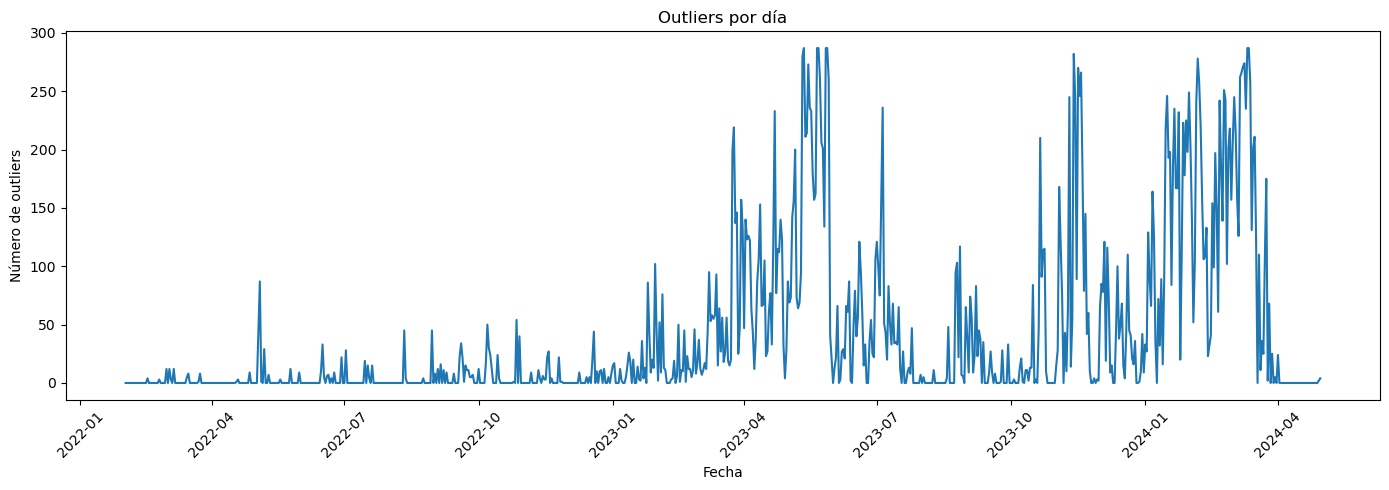

In [48]:
clustering_data_all['date'] = pd.to_datetime(clustering_data_all['timestamp']).dt.date

total_by_day = clustering_data_all.groupby('date').size()
outliers_by_day = (clustering_data_all[clustering_data_all['outliers'] == True]
                   .groupby('date')
                   .size())
# Reindex con todos los días, llenando con 0
outliers_by_day = outliers_by_day.reindex(total_by_day.index, fill_value=0)

outliers_by_day = outliers_by_day.reset_index()
outliers_by_day.columns = ['date', 'outliers']

plt.figure(figsize=(14, 5))
plt.plot(outliers_by_day['date'], outliers_by_day['outliers'])
plt.xlabel('Fecha')
plt.ylabel('Número de outliers')
plt.title('Outliers por día')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
np.max(outliers_by_day['outliers'])

287

In [52]:
outliers_by_day.to_csv('../data/outliers/outliers_3g_qqplot.csv', index = False)

In [57]:
clustering_data_pred.head(10)

,energy_mobile_mean,kurtosis_mobile_mean,frequency_index_mobile_mean,entropy_mobile_mean,timestamp,labels,distance_to_centroid,outliers
8897,8.393811,1.661201,0.273803,2568.654698,2022-02-01 00:05:00,2,1.830622,False
8898,8.368427,1.661031,0.251328,2632.398663,2022-02-01 00:10:00,2,1.809466,False
8899,8.331916,1.660930,0.233178,2718.468674,2022-02-01 00:15:00,0,1.725136,False
8900,8.318658,1.660575,0.221038,2781.344684,2022-02-01 00:20:00,0,1.631353,False
8901,8.329291,1.775273,0.159708,2764.549794,2022-02-01 00:25:00,0,1.386021,False
8902,8.336428,1.848613,0.096582,2775.832282,2022-02-01 00:30:00,0,1.198708,False
8903,8.217167,1.732127,0.048982,2909.222234,2022-02-01 00:35:00,0,0.708212,False
8904,8.048208,1.527851,0.014230,3072.666078,2022-02-01 00:40:00,0,0.427429,False
8905,8.034143,1.538598,0.031505,3125.241550,2022-02-01 00:45:00,0,0.460122,False
8906,8.026628,1.547211,0.045728,3154.608479,2022-02-01 00:50:00,0,0.509813,False


In [54]:
clustering_data_all = pd.concat([clustering_data, clustering_data_pred], axis=0)

In [55]:
clustering_data_all.head(10)

,PC1,PC2,PC3,labels,distance_to_centroid,outliers,energy_mobile_mean,kurtosis_mobile_mean,frequency_index_mobile_mean,entropy_mobile_mean,timestamp
0,2.093583,-0.309114,0.587753,1,1.205685,False,NaN,NaN,NaN,NaN,NaT
1,1.867200,-0.188118,0.922386,1,1.237926,False,NaN,NaN,NaN,NaN,NaT
2,1.618884,-0.169109,1.240274,1,1.376366,False,NaN,NaN,NaN,NaN,NaT
3,1.624468,-0.190031,1.254425,1,1.392096,False,NaN,NaN,NaN,NaN,NaT
4,1.677512,-0.163761,1.226588,1,1.388604,False,NaN,NaN,NaN,NaN,NaT
5,1.664216,-0.214508,1.284773,1,1.437030,False,NaN,NaN,NaN,NaN,NaT
6,1.845154,-0.190238,1.314180,1,1.545753,False,NaN,NaN,NaN,NaN,NaT
7,2.009945,-0.184887,1.355728,1,1.669037,False,NaN,NaN,NaN,NaN,NaT
8,1.959393,-0.241060,1.433816,1,1.709182,False,NaN,NaN,NaN,NaN,NaT
9,2.098498,-0.421087,1.473671,1,1.836875,False,NaN,NaN,NaN,NaN,NaT


una vez que se vaya a reentrenar el algoritmo con los outliers, hay que volver a correr el PCA y el K-Medias

Serie de tiempo de anomalias

Cada punto que tenemos está en un espacio de cuatro dimensiones

Devolver al espacio de una dimensión de la serie de tiempo original?

Cómo la regreso a una serie de tiempo de una variable?

Derivada de la distancia coseno de la serie de tiempo?

El promedio de las últimas diferencias, una media y una dispersión

Noción de anomalia

Cada punto en el tiempo es una dimensión

Revisar para la tercera corrida de mayo de 2022
Solo hacer el clustering para los nuevos datos
Para los outliers detectados, correr el clustering y crear nuevas bolsas


# Generating new groups

In [79]:
clustering_data_pred.head()

,energy_mobile_mean,kurtosis_mobile_mean,frequency_index_mobile_mean,entropy_mobile_mean,timestamp,labels,distance_to_centroid,outliers
8897,8.393811,1.661201,0.273803,2568.654698,2022-02-01 00:05:00,2,1.830622,False
8898,8.368427,1.661031,0.251328,2632.398663,2022-02-01 00:10:00,2,1.809466,False
8899,8.331916,1.660930,0.233178,2718.468674,2022-02-01 00:15:00,0,1.725136,False
8900,8.318658,1.660575,0.221038,2781.344684,2022-02-01 00:20:00,0,1.631353,False
8901,8.329291,1.775273,0.159708,2764.549794,2022-02-01 00:25:00,0,1.386021,False


In [92]:
clustering_outliers = clustering_data_pred[(clustering_data_pred['outliers']==True) & (clustering_data_pred['timestamp']>='2023-01-25')]

In [93]:
len(clustering_outliers)

32005

In [94]:
# Take descriptive variables
variables = ["energy_mobile_mean",	"kurtosis_mobile_mean", "frequency_index_mobile_mean", "entropy_mobile_mean"]
X_outliers = clustering_outliers[["energy_mobile_mean",	"kurtosis_mobile_mean",	
                         "frequency_index_mobile_mean", "entropy_mobile_mean"]].to_numpy()

In [95]:
# Scale variables
scaler_outliers = StandardScaler().fit(X_outliers)
X_outliers = scaler_outliers.transform(X_outliers)

# PCA

In [96]:
# Train a PCA model
pcs = PCA(n_components=4).fit(X_outliers)
# Report PCA summary
pcsSummary = pd.DataFrame({'Standard deviation': np.sqrt(pcs.explained_variance_),
                           'Proportion of variance': pcs.explained_variance_ratio_,
                           'Cumulative variance': np.cumsum(pcs.explained_variance_ratio_)})

pcsSummary = pcsSummary.transpose()
pcsSummary.columns = ['PC'+str(ind) for ind in range(1, 5)]
pcsSummary.round(3)

,PC1,PC2,PC3,PC4
Standard deviation,1.325,1.129,0.817,0.551
Proportion of variance,0.439,0.319,0.167,0.076
Cumulative variance,0.439,0.757,0.924,1.000


In [97]:
# See the weights for each PC
pcsComponents = pd.DataFrame(pcs.components_.transpose(),
                             columns=['PC'+str(ind) for ind in range(1, 5)],
                             index= variables)

pcsComponents

,PC1,PC2,PC3,PC4
energy_mobile_mean,-0.393761,-0.531346,0.736287,0.143196
kurtosis_mobile_mean,0.588762,-0.439644,0.127171,-0.666259
frequency_index_mobile_mean,0.180150,0.714799,0.648867,-0.188628
entropy_mobile_mean,0.682538,-0.115962,0.143808,0.707117


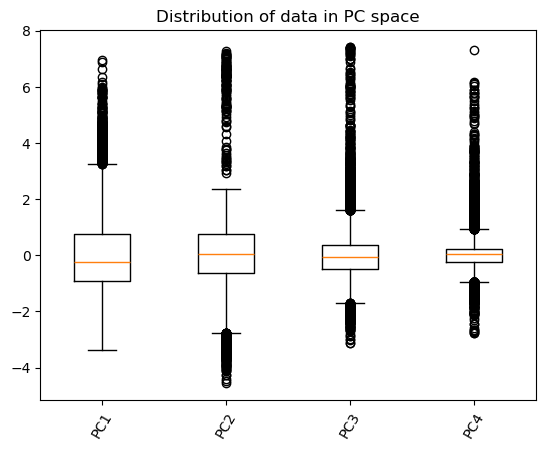

In [98]:
Z_outliers = pd.DataFrame(pcs.transform(X_outliers), columns=['PC'+str(ind) for ind in range(1, 5)])

# Plot distribution of data
plt.title('Distribution of data in PC space')
plt.boxplot(pcs.transform(X_outliers))
plt.xticks(ticks=range(1, 5), labels=['PC'+str(ind) for ind in range(1, 5)], rotation=60)
plt.show()

In [99]:
# Create a PCA object and train it
pca_outliers = PCA(n_components=3).fit(X_outliers)
# Transform the data to the new reducted space
Z_outliers = pca.transform(X_outliers)

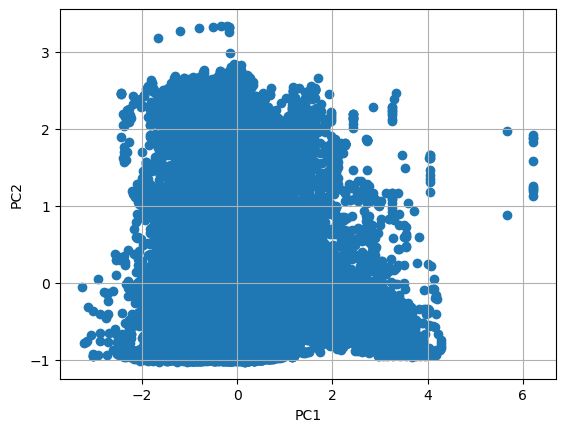

In [100]:
# Plot in the new space
plt.scatter(X_outliers[:, 0], X_outliers[:, 1])
plt.grid()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# Clustering

In [102]:
# Try with different number of groups
inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model = KMeans(n_clusters=k).fit(Z_outliers)
  inertia.append(km_model.inertia_)
  silh.append(silhouette_score(Z_outliers, km_model.labels_))

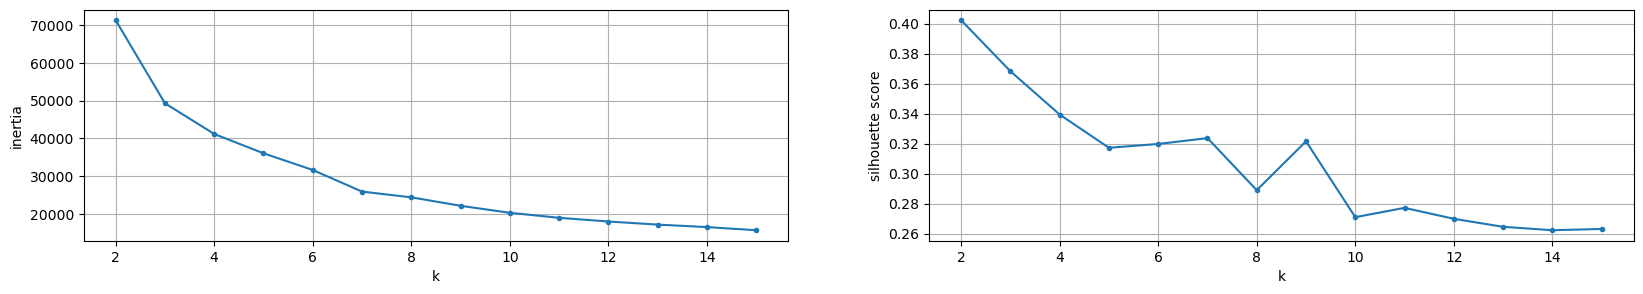

In [103]:
# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

In [104]:
import random
import numpy as np



# Run KMeans multiple times and keep the best model
n_iterations = 100  # Number of times to run KMeans
n_clusters = 3

best_model = None
best_labels = None
best_score = -np.inf
best_seed = None

for i in range(n_iterations):
    seed = random.randint(1, 10000)
    km_temp = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10).fit(Z_outliers)
    labels_temp = km_temp.labels_
    score = silhouette_score(Z_outliers, labels_temp)

    if score > best_score:
        best_score = score
        best_model = km_temp
        best_labels = labels_temp
        best_seed = seed

km_model = best_model
km_model.labels_ = best_labels

print(f"\nBest silhouette score: {best_score:.4f}")
print(best_seed)

KeyboardInterrupt: 